In [ ]:
%cd pneumonia_detection
!pwd
!ls

[Errno 2] No such file or directory: 'pneumonia_detection'
/content
/content
sample_data


In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
!ls


In [ ]:
!unzip -q pneumonia_detection.zip
!ls

In [ ]:
%cd /content/pneumonia_detection
!ls

In [ ]:
!pip install -r requirements.txt

In [ ]:
%cd /content/pneumonia_detection


In [ ]:
!ls

In [ ]:
!find data -maxdepth 3

In [ ]:
!nvidia-smi


In [ ]:
!pip install --upgrade ml-dtypes
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

In [ ]:
from google.colab import files
files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
import os

for root, dirs, files in os.walk("/content/pneumonia_data"):
    print(root)

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Pneumonia_Detection', 'Resume (4).pdf', 'Resume (3).pdf', 'Resume (2).pdf', 'Scanned_20220716-2130.pdf', 'IMG-20220720-WA0003.jpg', 'IMG-20220720-WA0004.jpg', 'IMG-20220720-WA0005.jpg', 'Screenshot_2022-11-30-21-39-30-32_40deb401b9ffe8e1df2f1cc5ba480b12.jpg', 'IV B-Div 2022-23(Even) B', 'IV Sem CS- A & B 2022-2023', 'UHV-II', 'Classroom', 'Screenshot_2023-09-07-13-49-52-86_50d9e451f83734a5732e78ed524de96f.jpg', 'IMG-20240517-WA0012 (1).jpg', 'IMG-20240517-WA0011 (1).jpg', 'IMG-20240517-WA0012.jpg', 'IMG-20240517-WA0011.jpg', 'IMG-20240516-WA0040(1) (3).jpg', 'IMG-20231018-WA0011 (1).jpg', 'IMG-20240516-WA0040(1) (2).jpg', 'Share vaishi123-1 (1).docx', 'photos  (1)', 'photos ', 'IMG-20240731-WA0003 (3).jpg', 'Screenshot_2024-09-11-18-52-54-99_c37d74246d9c81aa0bb824b57eaf7062.jpg', 'Screenshot_2024-09-11-18-53-00-69_c37d74246d9c81aa0bb824b57eaf7062.jpg', 'Screenshot_2024-09-11-18-53-30-75_c37d74246d9c81aa0bb824b57eaf7062.jpg', 'Screenshot_2024-09-11-18-53-43-49_c37d74246d9c81aa0bb824b5

In [ ]:
print(os.listdir("/content/drive/MyDrive/Pneumonia_Detection"))

['Pneumonia_Detection.ipynb', 'archive (1).zip', 'pneumonia_densenet121.keras', 'accuracy.png', 'loss.png']


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Pneumonia_Detection/archive (1).zip"
extract_path = "/content/pneumonia_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/pneumonia_data"):
    print(root)

/content/pneumonia_data
/content/pneumonia_data/chest_xray
/content/pneumonia_data/chest_xray/chest_xray
/content/pneumonia_data/chest_xray/chest_xray/train
/content/pneumonia_data/chest_xray/chest_xray/train/NORMAL
/content/pneumonia_data/chest_xray/chest_xray/train/PNEUMONIA
/content/pneumonia_data/chest_xray/chest_xray/test
/content/pneumonia_data/chest_xray/chest_xray/test/NORMAL
/content/pneumonia_data/chest_xray/chest_xray/test/PNEUMONIA
/content/pneumonia_data/chest_xray/chest_xray/val
/content/pneumonia_data/chest_xray/chest_xray/val/NORMAL
/content/pneumonia_data/chest_xray/chest_xray/val/PNEUMONIA
/content/pneumonia_data/chest_xray/__MACOSX
/content/pneumonia_data/chest_xray/__MACOSX/chest_xray
/content/pneumonia_data/chest_xray/__MACOSX/chest_xray/train
/content/pneumonia_data/chest_xray/__MACOSX/chest_xray/train/NORMAL
/content/pneumonia_data/chest_xray/__MACOSX/chest_xray/train/PNEUMONIA
/content/pneumonia_data/chest_xray/__MACOSX/chest_xray/test
/content/pneumonia_data/ch

In [ ]:
train_path = "/content/pneumonia_data/chest_xray/train"
val_path = "/content/pneumonia_data/chest_xray/val"
test_path = "/content/pneumonia_data/chest_xray/test"

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 168s 831ms/step - accuracy: 0.6589 - loss: 0.6161 - val_accuracy: 0.8125 - val_loss: 0.4284
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 704ms/step - accuracy: 0.7966 - loss: 0.4226 - val_accuracy: 0.8125 - val_loss: 0.3810
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 702ms/step - accuracy: 0.8238 - loss: 0.3754 - val_accuracy: 0.8750 - val_loss: 0.3692
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 697ms/step - accuracy: 0.8466 - loss: 0.3429 - val_accuracy: 0.7500 - val_loss: 0.3492
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 718ms/step - accuracy: 0.8530 - loss: 0.3384 - val_accuracy: 0.8125 - val_loss: 0.3749
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 749ms/step - accuracy: 0.8558 - loss: 0.3196 - val_accuracy: 0.7500 - val_loss: 0.3368
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 720ms/step - accuracy: 0.8700 - loss: 0.3004 - val_accuracy: 0.8125 - val_loss: 0.3427
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 712ms/step - accuracy: 0.8760 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 357ms/step - accuracy: 0.8846 - loss: 0.2834
Test Loss: 0.28343483805656433
Test Accuracy: 0.8846153616905212


In [ ]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 912ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_generator.classes,
    predicted_classes,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.87      0.81      0.84       234
   PNEUMONIA       0.89      0.93      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.87      0.88       624
weighted avg       0.88      0.88      0.88       624



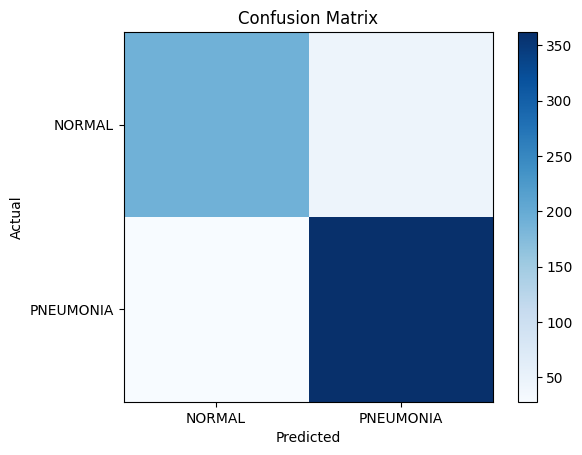

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(test_generator.classes, predicted_classes)

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["NORMAL","PNEUMONIA"])
plt.yticks([0,1], ["NORMAL","PNEUMONIA"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

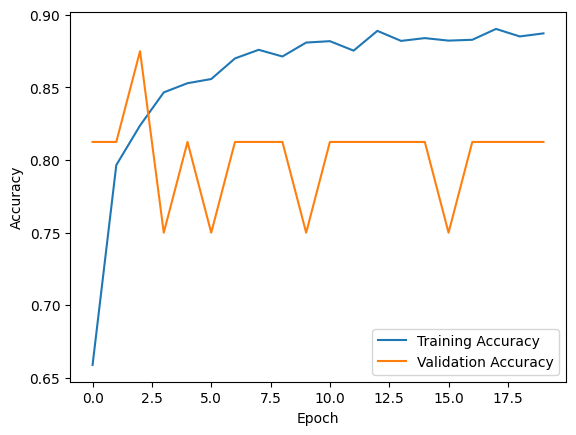

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

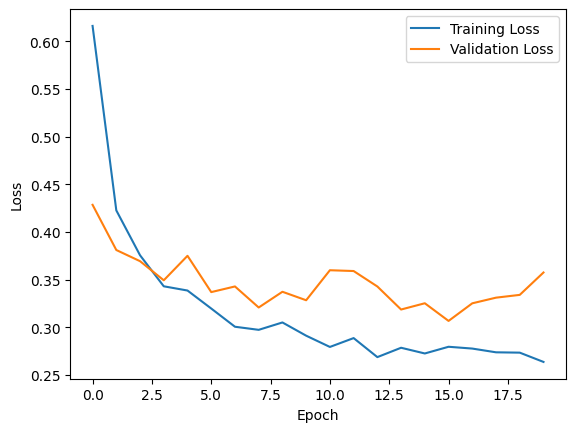

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/Pneumonia_Detection/pneumonia_densenet121.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/Pneumonia_Detection/pneumonia_densenet121.keras")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving x-ray.jpg to x-ray.jpg


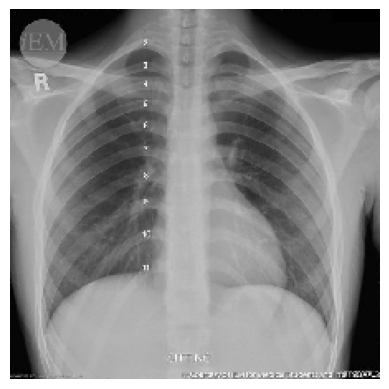

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "x-ray.jpg"   # Replace with your uploaded filename

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
label = "PNEUMONIA" if prediction[0][0] > 0.5 else "NORMAL"
confidence = prediction[0][0] if label == "PNEUMONIA" else (1 - prediction[0][0])

print("=" * 40)
print("Chest X-ray Prediction")
print("=" * 40)
print(f"Result     : {label}")
print(f"Confidence : {confidence * 100:.2f}%")
print("=" * 40)

Chest X-ray Prediction
Result     : NORMAL
Confidence : 77.76%


In [33]:
plt.savefig("/content/drive/MyDrive/Pneumonia_Detection/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>